# Импорты

In [ ]:
!git clone https://github.com/evagogua/denoiseML

Cloning into 'denoiseML'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 104 (delta 30), reused 45 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 6.01 MiB | 3.55 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
!pip install -r "/content/denoiseML/requirements.txt"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 15.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 1.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a

In [ ]:
import sys
import os

repo_name = "denoiseML"
os.chdir(f'/content/{repo_name}')

from src.models.denoise_model import (
    DenoiseDataset as DenoiseDatasetModel,
    make_last_subtoken_mask,
    prepare_denoise_dataset_from_json
)

from src.inference.denoiser import (
    denoising,
    predict_with_trainer as predict_with_trainer_denoise,
    evaluate_on_test_set as evaluate_on_test_set_denoise,
    test as denoise_test_data
)
from src.models.trainer import (
    plot_training_curves,
    compute_metrics as compute_metrics_training,
    final_report as final_report_training
)

from src.models.classifier_model import (
    ClassificationDataset,
    prepare_classification_dataset_from_json
)

from src.inference.classifier import (
    predict_with_trainer_seq,
    get_simple_metrics,
    compute_metrics_simple
)

# Обучение

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForSequenceClassification

class_model = AutoModelForSequenceClassification.from_pretrained("FacebookAI/xlm-roberta-base")
class_tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Обучение классификационной модели на чистых данных

In [ ]:
train_class_data, test_class_data = prepare_classification_dataset_from_json('/content/denoiseML/data/clean_data_bctw.json', class_tokenizer)

Generating train split: 0 examples [00:00, ? examples/s]

Пример из train (исходные данные):
{'text': ['сколько', 'я', 'должен', 'заплатить', 'в', 'этом', 'месяце'], 'classification_labels': 'bill_balance'}

Пример из train (после токенизации):
{'input_ids': tensor([    0, 47381,   784, 15856, 94446,  1117,    49,  3920, 45666,   103,
            2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]), 'labels': tensor(4)}



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

class_model = AutoModelForSequenceClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=len(train_class_data.tags_))
optimizer = AdamW(class_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=200, disable_tqdm=False,
                  metric_for_best_model='accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
class_trainer = Trainer(
    model=class_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorWithPadding(tokenizer=class_tokenizer),
    train_dataset=train_class_data,
    eval_dataset=test_class_data,
    compute_metrics=compute_metrics_simple)
class_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib

Step,Training Loss,Validation Loss


KeyboardInterrupt: 

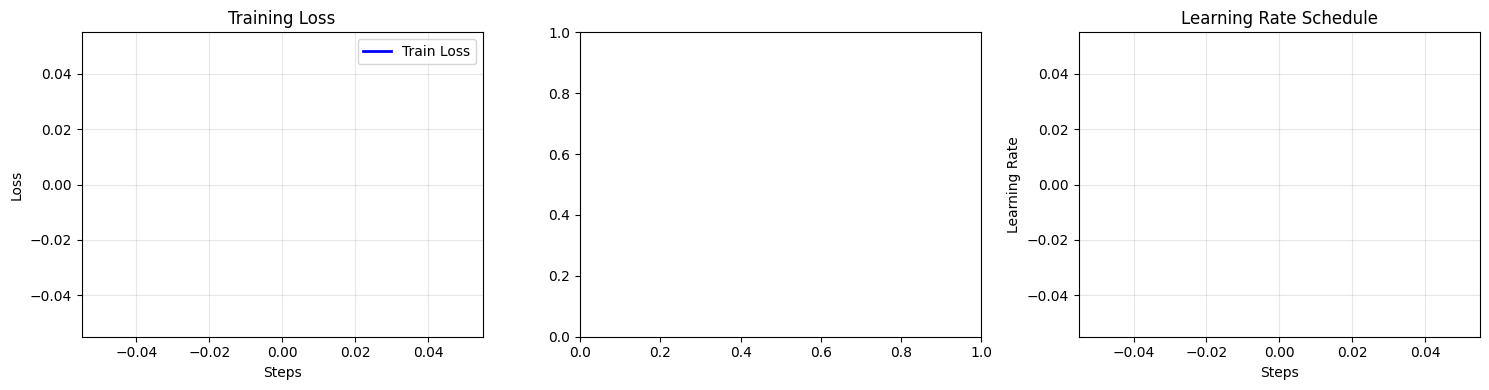

In [ ]:
plot_training_curves(class_trainer)

In [ ]:
model_save_path = "class_model"
class_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Классификация шумных данных

In [ ]:
train_class_noise_data, test_class_noise_data = prepare_classification_dataset_from_json('/content/denoiseML/data/noise_data_bctw.json', class_tokenizer)

Generating train split: 0 examples [00:00, ? examples/s]

Пример из train (исходные данные):
{'text': ['сколько', 'я', 'должен', 'заплатить', 'ась', 'где', 'в', 'та', 'надоели', 'этом', 'месяце'], 'denoise_labels': ['0', '0', '0', '0', 'N', 'N', '0', 'N', 'N', '0', '0'], 'classification_labels': 'bill_balance'}

Пример из train (после токенизации):
{'input_ids': tensor([    0, 47381,   784, 15856, 94446,  1117,     6, 43460,  4851,    49,
          489, 11064, 22940,  3920, 45666,   103,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]), 'labels': tensor(4)}



In [ ]:
import numpy as np
from scipy.special import softmax
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

pred_labels, pred_probs = predict_with_trainer_seq(
    class_trainer,
    test_class_noise_data,
    classes=train_class_noise_data.tags_
)

true_labels = [train_class_noise_data.id_to_label[item["labels"].item()] for item in test_class_noise_data]

metrics = get_simple_metrics(true_labels, pred_labels)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

## Классификация очищенных данных

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch

model_name = "evagogua/tw_bc_denoise_model"

tw_bc_denoise_tokenizer = AutoTokenizer.from_pretrained(model_name)
tw_bc_denoise_model = AutoModelForTokenClassification.from_pretrained(model_name)
tw_bc_denoise_model_trainer = Trainer(
    model=tw_bc_denoise_model,
    args=TrainingArguments(
        output_dir="tw_bc_denoise_model_trainer",
        report_to="none"
    ),
    data_collator=DataCollatorForTokenClassification(tokenizer=tw_bc_denoise_tokenizer)
)

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
test_noise_data = prepare_classification_dataset_from_json('/content/denoiseML/data/noise_data_bctw.json', tw_bc_denoise_tokenizer, raw=True)[1]

NameError: name 'tw_bc_denoise_tokenizer' is not defined

In [ ]:
from datasets import Dataset
def denoising(data_samples, tr, tokenizer, tag):
  biganswer = []
  test_dataset = DenoiseDataset(data_samples, tokenizer)
  predictions = predict_with_trainer(tr, test_dataset, classes=test_dataset.tags_)
  for item, probs in zip(data_samples, predictions):
    new_sample = {"text":[token for token, mask in zip(item['text'], probs['labels']) if mask == '0'], 'denoise_labels': item["denoise_labels"], 'classification_labels': item["classification_labels"]}
    masked = [item for item in predictions[0]["labels"] if item != -100]
    biganswer.append(new_sample)
  return biganswer

cleaned_data = denoising(test_noise_data, tw_bc_denoise_model_trainer, tw_bc_denoise_tokenizer, ["N", "0"])

hf_dataset = Dataset.from_list(cleaned_data)

denoised_dataset = ClassificationDataset(
    data=hf_dataset,
    tokenizer=class_tokenizer
)

NameError: name 'test_noise_data' is not defined

In [ ]:
import numpy as np
from scipy.special import softmax
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

pred_labels, pred_probs = predict_with_trainer_seq(
    class_trainer,
    denoised_dataset,
    classes=train_class_noise_data.tags_
)

true_labels = [train_class_noise_data.id_to_label[item["labels"].item()] for item in denoised_dataset]

metrics = get_simple_metrics(true_labels, pred_labels)